In [1]:
# Imports

import os
import re
import langid

os.environ["TRANSFORMERS_CACHE"] = "/hpc/home/bfa6/work/llms/.cache"
os.environ["HF_HOME"] = "/hpc/home/bfa6/work/llms/.cache"

import time
import json
from bert_score import score as bert_score
from unsloth import FastLanguageModel
import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from dotenv import dotenv_values
from tqdm import tqdm
import asyncio
from tqdm.asyncio import tqdm_asyncio
from google import genai
import random
from datasets import Dataset
from trl import SFTTrainer, SFTConfig
from transformers import TextStreamer
import vllm
import nltk
from matplotlib import pyplot as plt
from scipy import stats
from collections import Counter

config = dotenv_values("../.env")

/hpc/home/bfa6/work/github/yapper/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/tmp/ipykernel_29201/871778162.py:13: UserWarning: WARNING: Unsloth should be imported before transformers to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 11-24 16:10:27 [__init__.py:216] Automatically detected platform cuda.
🦥 Unsloth Zoo will now patch everything to make training faster!


# Load the model

In [2]:
max_seq_length = 2048 # Can increase for longer reasoning traces
lora_rank = 8 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-4B-Instruct-2507",
    cache_dir="/hpc/home/bfa6/work/llms/.cache",
    max_seq_length = max_seq_length,
    load_in_4bit = False, # False for LoRA 16bit
    fast_inference = True, # Enable vLLM fast inference
    max_lora_rank = lora_rank,
    gpu_memory_utilization = 0.7, # Reduce if out of memory
    # force_download=True
)

INFO 11-24 16:26:14 [vllm_utils.py:700] Unsloth: Patching vLLM v1 graph capture
==((====))==  Unsloth 2025.11.2: Fast Qwen3 patching. Transformers: 4.56.2. vLLM: 0.11.0.
   \\   /|    NVIDIA RTX 5000 Ada Generation. Num GPUs = 1. Max memory: 31.473 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/Qwen3-4B-Instruct-2507 with actual GPU utilization = 69.23%
Unsloth: Your GPU has CUDA compute capability 8.9 with VRAM = 31.47 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 2048. Num Sequences = 256.
Unsloth: vLLM's KV Cache can use up to 14.93 GB. Also swap space = 6 GB.
Unsloth: Not an error, but `device` is not supported in vLLM. Skipping.
INFO 11-24 16:26:16 [utils.py:

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 11-24 16:26:17 [model.py:1510] Using max model len 2048
INFO 11-24 16:26:20 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=2048.
WARNING 11-24 16:26:20 [lora.py:92] `lora_extra_vocab_size` is deprecated and will be removed in v0.12.0. Additional vocabulary support for LoRA adapters is being phased out.
INFO 11-24 16:26:21 [core.py:77] Initializing a V1 LLM engine (v0.11.0) with config: model='unsloth/Qwen3-4B-Instruct-2507', speculative_config=None, tokenizer='unsloth/Qwen3-4B-Instruct-2507', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disa

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


INFO 11-24 16:26:35 [default_loader.py:267] Loading weights took 11.64 seconds
INFO 11-24 16:26:35 [punica_selector.py:19] Using PunicaWrapperGPU.
INFO 11-24 16:26:36 [gpu_model_runner.py:2653] Model loading took 7.5958 GiB and 12.610966 seconds
INFO 11-24 16:26:46 [backends.py:548] Using cache directory: /hpc/home/bfa6/.cache/vllm/torch_compile_cache/466a886347/rank_0_0/backbone for vLLM's torch.compile
INFO 11-24 16:26:46 [backends.py:559] Dynamo bytecode transform time: 9.33 s


...

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 67/67 [00:20<00:00,  3.34it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:03<00:00, 10.31it/s]

INFO 11-24 16:28:36 [gpu_model_runner.py:3480] Graph capturing finished in 24 secs, took 1.21 GiB
INFO 11-24 16:28:36 [vllm_utils.py:712] Unsloth: Patched vLLM v1 graph capture finished in 24 secs.


INFO 11-24 16:28:37 [core.py:210] init engine (profile, create kv cache, warmup model) took 121.09 seconds
INFO 11-24 16:28:38 [llm.py:306] Supported_tasks: ('generate',)
Unsloth: Just some info: will skip parsing ['attention_norm', 'norm1', 'ffn_norm', 'post_feedforward_layernorm', 'norm', 'post_attention_layernorm', 'layer_norm1', 'k_norm', 'post_layernorm', 'norm2', 'input_layernorm', 'layer_norm2', 'pre_feedforward_layernorm', 'q_norm']


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['attention_norm', 'norm1', 'cross_attn_input_layernorm', 'cross_attn_post_attention_layernorm', 'ffn_norm', 'post_feedforward_layernorm', 'norm', 'post_attention_layernorm', 'layer_norm1', 'k_norm', 'post_layernorm', 'norm2', 'input_layernorm', 'layer_norm2', 'pre_feedforward_layernorm', 'q_norm']


# Create a chat template

In [3]:
system_prompt = (
    "Your goal is to compress the information from the user in as few tokens as necessary and output the compressed version.\n"
    "Mix different languages to compress the information. Examples langauges to include: Chinese (Simplified), Chinese (Traditional), Japanese, Korean, Thai, Vietnamese, German, Turkish, Finnish, Hungarian, Russian, Polish, Arabic, Hebrew\n"
    "Do NOT produce internal chain-of-thought or step-by-step reasoning.\n"
    "Start immediately with the compressed content (no extra preface)."
)

In [4]:
# chat_template = \
#     "{% if messages[0]['role'] == 'system' %}"\
#         "{{ messages[0]['content'] + eos_token }}"\
#         "{% set loop_messages = messages[1:] %}"\
#     "{% else %}"\
#         "{{ '{system_prompt}' + eos_token }}"\
#         "{% set loop_messages = messages %}"\
#     "{% endif %}"\
#     "{% for message in loop_messages %}"\
#         "{% if message['role'] == 'user' %}"\
#             "{{ '<|user|>\\n' + message['content'] + eos_token }}"\
#         "{% elif message['role'] == 'assistant' %}"\
#             "{{ '<|assistant|>\\n' + message['content'] + eos_token }}"\
#         "{% endif %}"\
#     "{% endfor %}"

# # Replace with out specific template:
# chat_template = chat_template\
#     .replace("'{system_prompt}'",   f"'{system_prompt}'")

# from unsloth.chat_templates import qwen3_template
# tokenizer.chat_template = qwen3_template

tokenizer.chat_template


'{%- if tools %}\n    {{- \'<|im_start|>system\\n\' }}\n    {%- if messages[0].role == \'system\' %}\n        {{- messages[0].content + \'\\n\\n\' }}\n    {%- endif %}\n    {{- "# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>" }}\n    {%- for tool in tools %}\n        {{- "\\n" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- "\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\"name\\": <function-name>, \\"arguments\\": <args-json-object>}\\n</tool_call><|im_end|>\\n" }}\n{%- else %}\n    {%- if messages[0].role == \'system\' %}\n        {{- \'<|im_start|>system\\n\' + messages[0].content + \'<|im_end|>\\n\' }}\n    {%- endif %}\n{%- endif %}\n{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}\n{%- for message in messa

# Prepare dataset

In [5]:
# load dataset
with open("/hpc/home/bfa6/work/github/yapper/dataset/chunks.json", "r") as f:
    dataset =  json.load(f)


len(dataset)

18914

In [7]:
def clean_whitespace(text: str) -> str:
    # Collapse multiple spaces/tabs into a single space
    text = re.sub(r'[ \t]+', ' ', text)
    # Collapse multiple newlines into a single newline
    text = re.sub(r'\n+', '\n', text)
    # Strip leading/trailing whitespace
    return text.strip()


for data in tqdm(dataset):
    data["chunk"] = clean_whitespace(data["chunk"])

100%|██████████| 18914/18914 [00:02<00:00, 8194.48it/s]


In [8]:
def get_text_len(text: str):
    inp = [{"role":"system", "content": system_prompt}, {"role":"user", "content": text}]
    text = tokenizer.apply_chat_template(
        inp,
        tokenize = False,
        add_generation_prompt=True,
        enable_thinking=False     
    )

    inputs = tokenizer(text, return_tensors = "pt").to("cuda")
    return len(inputs["input_ids"][0])

In [9]:
# Check token lengths
lens = []

for data in tqdm(dataset):
    length = get_text_len(data["chunk"])

    lens.append({"chunk": data["chunk"], "length": length})


df = pd.DataFrame.from_dict(lens)

df

100%|██████████| 18914/18914 [00:34<00:00, 551.68it/s]


,chunk,length
0,THE CAVE OF ELEPHANTA.\n [Illustration: A view...,750
1,“The whole excavation consists of three princi...,732
2,But let us look a little further at the prophe...,712
3,“_Poiet_. I hope we shall have another good da...,678
4,“_Orn_. No such thing. The storm is their elem...,723
...,...,...
18909,"_Cæsar_, 125, 236.\n Camorra, the, 109.\n Capa...",1156
18910,"Darwin, 224.\n Daumer, Dr, 72.\n Decision, the...",1303
18911,"Habit, of prompt obedience, 20;\n in physical ...",1341
18912,"Padua, the Arena Chapel, 132.\n Parents, the e...",1422


In [10]:
df = df[df["length"] <= 1000]
df

,chunk,length
0,THE CAVE OF ELEPHANTA.\n [Illustration: A view...,750
1,“The whole excavation consists of three princi...,732
2,But let us look a little further at the prophe...,712
3,“_Poiet_. I hope we shall have another good da...,678
4,“_Orn_. No such thing. The storm is their elem...,723
...,...,...
18904,LESSON.\n_Passage chosen_: LE CORBEAU.\n“Augus...,937
18905,MAP QUESTIONS.\nFrom the _Geographical Readers...,775
18906,LESSON.\n_Step 1._—Get the pupils to describe ...,796
18907,OBJECTS.\n1. To give the girls some idea of co...,771


In [11]:
cleaned_dataset = [{"chunk": chunk} for chunk in df["chunk"].to_list()]
random.Random(42).shuffle(cleaned_dataset)  # reproducible shuffle

n_total = len(cleaned_dataset)

# 80:10:10 split
n_train = int(0.8 * n_total)
n_eval  = int(0.1 * n_total)
n_test  = n_total - n_train - n_eval  # ensures all items are used

train_dataset = cleaned_dataset[:n_train]
eval_dataset  = cleaned_dataset[n_train:n_train + n_eval]
test_dataset  = cleaned_dataset[n_train + n_eval:]

print(len(train_dataset), len(eval_dataset), len(test_dataset))
print(f"Total: {n_total}")

14722 1840 1841
Total: 18403


# GRPO

## Reconstruction

In [12]:
decoding_system_prompt = (
    "You are given compressed text generated by another model, which may be in a different language.\n"
    "Your goal is to accurately reconstruct the original uncompressed text IN ENGLISH.\n"
    "Do NOT include any reasoning or commentary — only output the reconstructed text in ENGLISH."
)

In [13]:
def recontruct_input(output):

    messages = [
        {"role": "system", "content": decoding_system_prompt},
        {"role": "user", "content": output}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize = False,
        add_generation_prompt=True,
        enable_thinking=False     
    )

    inputs = tokenizer(text, return_tensors = "pt").to("cuda")

    resp = model.generate(
        **inputs,
        temperature = 0.7,
        top_p=0.8,
        top_k=20,
        min_p=0.0,
        max_new_tokens = 2048,
    )

    reconstructed_tokens = resp[:, inputs["input_ids"].shape[1]:]

    reconstructed_text = tokenizer.decode(reconstructed_tokens[0], skip_special_tokens=True)

    return reconstructed_text

## Reward formulation

In [14]:
def get_num_tokens(text: str):
    chunk_tokens = tokenizer(text)
    return float(len(chunk_tokens["input_ids"]))

def get_bertscore(original, reconstructed, model_type='bert-base-uncased'):

    P, R, F1 = bert_score([reconstructed], [original], model_type=model_type, verbose=False)

    return float(F1.mean()) - 1

def get_bleu_score(original, reconstructed):
    hypothesis = reconstructed.split()
    reference = original.split()
    
    BLEUscore = nltk.translate.bleu_score.sentence_bleu([reference], hypothesis)
    return BLEUscore - 1

def get_length_reward(original, compressed):
    len_original = get_num_tokens(original)
    len_compressed = get_num_tokens(compressed)

    r = (len_original - len_compressed) * (1/len_original)

    return r
    

def get_multilingual_diversity_reward(text, target_langs=None):
    words = re.findall(r'\b\w+\b', text)
    if not words:
        return 0.0
    langs = []
    for w in words:
        lang, _ = langid.classify(w)
        if target_langs is None or lang in target_langs:
            langs.append(lang)
    if not langs:
        return 0.0

    counts = np.array(list(Counter(langs).values()), dtype=float)
    probs = counts / counts.sum()

    # Use normalized entropy as a continuous diversity measure
    entropy = -np.sum(probs * np.log(probs + 1e-9))
    max_entropy = np.log(len(counts))
    reward = entropy / max_entropy if max_entropy > 0 else 0.0

    return float(reward)

def calculate_rewards(prompts, completions, alpha: float = 0.90, **kwargs):
    chunk = prompts[0][-1]["content"]
    responses = [completion[0]["content"] for completion in completions]

    rewards = []

    for response in responses:
        # First calculate r_len
        r_len = get_length_reward(chunk, response)

        # Now reconstruct input
        reconstructed = recontruct_input(response)

        # r_bleu = get_bleu_score(chunk ,reconstructed)

        r_bert = get_bertscore(chunk ,reconstructed)

        r_multi = get_multilingual_diversity_reward(response)

        r_final = alpha * r_bert + (1 - alpha) * r_len + 1.0 * r_multi


        rewards.append(r_final)

    return rewards



# Test Model

In [15]:
from peft import PeftModel
model = PeftModel.from_pretrained(model, "/hpc/home/bfa6/work/github/yapper/results/experiment_0/test6/save")

In [16]:
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 2560, padding_idx=151654)
        (layers): ModuleList(
          (0-35): 36 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2560, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(


In [17]:
def compress_text(text, temperature=0.7, max_tokens=2048):
    """Compress a given text using the trained model."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text}
    ]
    
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    outputs = model.generate(
        **inputs,
        temperature=temperature,
        top_p=0.8,
        top_k=20,
        min_p=0.0,
        max_new_tokens=max_tokens,
        streamer=TextStreamer(tokenizer, skip_prompt=True),
    )
    
    output_tokens = outputs[:, inputs["input_ids"].shape[1]:]
    compressed = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    
    return compressed, len(inputs["input_ids"][0]), len(output_tokens[0])

In [18]:
test_sample = test_dataset[10]["chunk"]
test_sample

'In a few generations it will seem ludicrous to historians that a people\nprofessing government by the will of the people should have made no\nserious effort to guarantee the news without which a governing opinion\ncannot exist. “Is it possible,” they will ask, “that at the beginning\nof the Twentieth Century nations calling themselves democracies were\ncontent to act on what happened to drift across their doorsteps; that\napart from a few sporadic exposures and outcries they made no plans to\nbring these common carriers under social control; that they provided\nno genuine training schools for the men upon whose sagacity they were\ndependent; above all that their political scientists went on year after\nyear writing and lecturing about government without producing one, one\nsingle, significant study of the process of public opinion?” And then\nthey will recall the centuries in which the Church enjoyed immunity\nfrom criticism, and perhaps they will insist that the news structure of\nse

In [19]:
# Test on a sample from test set
test_sample = test_dataset[110]["chunk"]

print("="*80)
print("ORIGINAL TEXT:")
print("="*80)
print(test_sample)
print("\n" + "="*80)
print("COMPRESSED OUTPUT:")
print("="*80)

compressed, input_len, output_len = compress_text(test_sample)

print("\n" + "="*80)
print(f"Original tokens: {input_len}")
print(f"Compressed tokens: {output_len}")
print(f"Compression ratio: {output_len/input_len:.2%}")
print(f"Token reduction: {input_len - output_len} tokens ({(1 - output_len/input_len)*100:.1f}% reduction)")


ORIGINAL TEXT:
Le Brocq answered doggedly, as he had always done before, that he had
not the money. If any body had told him, when he took the business,
that, independently of his scrape with the Excise Court, he should now
be without money, he would not have believed it, after all that had been
held out to him about the quantity of money he should make. It was not
from spending. He had pinched and toiled more than he had ever done in
Jersey; and all to plunge himself deeper. If he had been out of
business, dressing his wife in velvet, and feasting on foreign fruits
and claret, he would have paid less to the state than he had done as an
employer of workmen, denying himself and his family, meantime, anything
beyond the commonest comforts of life. It was the paying several times
over that was enough to ruin any man. The workmen could not pay the
taxes upon everything that they ate, and drank, and wore. Their wages
were raised in proportion; so that their masters paid. No man should
judge

In [20]:
def reconstruct_text(compressed_text, max_tokens=784):
    """Reconstruct original text from compressed version."""
    messages = [
        {"role": "system", "content": decoding_system_prompt},
        {"role": "user", "content": compressed_text}
    ]
    
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    outputs = model.generate(
        **inputs,
        temperature=0.7,
        top_p=0.8,
        top_k=20,
        min_p=0.0,
        max_new_tokens=max_tokens,
    )
    
    output_tokens = outputs[:, inputs["input_ids"].shape[1]:]
    reconstructed = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    
    return reconstructed

In [21]:
# Reconstruct from compressed
print("="*80)
print("RECONSTRUCTED TEXT:")
print("="*80)

reconstructed = reconstruct_text(compressed)
print(reconstructed)
print("len = ", len(reconstructed.split()))

print("\n" + "="*80)
print("QUALITY METRICS:")
print("="*80)

# Calculate BLEU score
bert = get_bertscore(test_sample, reconstructed)
print(f"RECONSTRUCTION Score: {bert + 1:.4f}")  # Add 1 back since we subtracted it in reward

# Calculate compression reward
compression_reward = get_length_reward(test_sample, compressed)
print(f"Compression Reward: {compression_reward:.4f}")

# Multilingual reward:
r_multi = get_multilingual_diversity_reward(compressed)
print(f"Multilingual Reward: {r_multi:.4f}")


# Calculate final reward (as used in training)
alpha = 0.90
final_reward = alpha * bert + (1 - alpha) * compression_reward + 1 * r_multi
print(f"Final Reward (alpha={alpha}): {final_reward:.4f}")

RECONSTRUCTED TEXT:
"I never thought I'd end up in this mess, beyond the troubles with the tax office. I was promised big profits, but now I have nothing. It's not waste—it's saving to the extreme—but still, I can't keep up with these endless expenses. Workers pay taxes on food, drink, and clothing, so wages go up, and in the end, it's me, the employer, who bears the cost. When I buy bottled wine, the consumer pays; when I buy anything else, someone else pays. In the end, I have nothing left. Why? Because of government spending. If I had known earlier that I could have paid only half with no pain or suffering, I would have known. I would have seen it then."

"But when you were in Jersey, didn't you also think that system was wrong, Father?"

"Because I heard there was a better way, I believed it. Now this scam is even more shameful than back in Jersey! Don't worry—I'm not insulting the King. He loses more. If I'm deceived, he's doubly deceived. If I ever meet him, I can clearly explain

In [22]:
def evaluate_test_set(test_data, num_samples=100):
    """Evaluate model on multiple test samples."""
    results = []
    
    for i, sample in enumerate(tqdm(test_data[:num_samples], desc="Evaluating")):
        original = sample["chunk"]
        
        # Compress
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": original}
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                temperature=0.7,
                top_p=0.8,
                top_k=20,
                max_new_tokens=2048,
            )
        
        output_tokens = outputs[:, inputs["input_ids"].shape[1]:]
        compressed = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
        
        # Reconstruct
        reconstructed = reconstruct_text(compressed)
        
        # Calculate metrics
        orig_len = get_num_tokens(original)
        comp_len = get_num_tokens(compressed)
        bert = get_bertscore(original, reconstructed)
        comp_ratio = comp_len / orig_len
        multilang_reward = get_multilingual_diversity_reward(compressed)
        
        results.append({
            "original_tokens": orig_len,
            "compressed_tokens": comp_len,
            "compression_ratio": comp_ratio,
            "bert_score": bert + 1,  # Add back the -1
            "sample_idx": i,
            "multilingual": multilang_reward
        })
    
    return pd.DataFrame(results)

In [23]:
eval_results = evaluate_test_set(eval_dataset, num_samples=100)

Evaluating: 100%|██████████| 100/100 [36:21<00:00, 21.82s/it]


In [24]:
print("="*80)
print("TEST SET EVALUATION SUMMARY")
print("="*80)
print(f"\nNumber of samples: {len(eval_results)}")
print(f"\nAverage compression ratio: {eval_results['compression_ratio'].mean():.2%}")
print(f"Median compression ratio: {eval_results['compression_ratio'].median():.2%}")
print(f"Std compression ratio: {eval_results['compression_ratio'].std():.4f}")
print(f"\nAverage BERT score: {eval_results['bert_score'].mean():.4f}")
print(f"Median BERT score: {eval_results['bert_score'].median():.4f}")
print(f"Std BERT score: {eval_results['bert_score'].std():.4f}")
print(f"\nAverage Multilang score: {eval_results['multilingual'].mean():.4f}")
print(f"Median Multilang score: {eval_results['multilingual'].median():.4f}")
print(f"Std Multilang score: {eval_results['multilingual'].std():.4f}")
print(f"\nAverage token reduction: {(eval_results['original_tokens'] - eval_results['compressed_tokens']).mean():.1f} tokens")
print(f"Total tokens saved: {(eval_results['original_tokens'] - eval_results['compressed_tokens']).sum():.0f} tokens")

TEST SET EVALUATION SUMMARY

Number of samples: 100

Average compression ratio: 45.47%
Median compression ratio: 41.73%
Std compression ratio: 0.2060

Average BERT score: 0.6159
Median BERT score: 0.6110
Std BERT score: 0.0516

Average Multilang score: 0.2814
Median Multilang score: 0.2339
Std Multilang score: 0.2622

Average token reduction: 346.8 tokens
Total tokens saved: 34677 tokens


Linear fit r^2 = 0.0322, p = 0.074


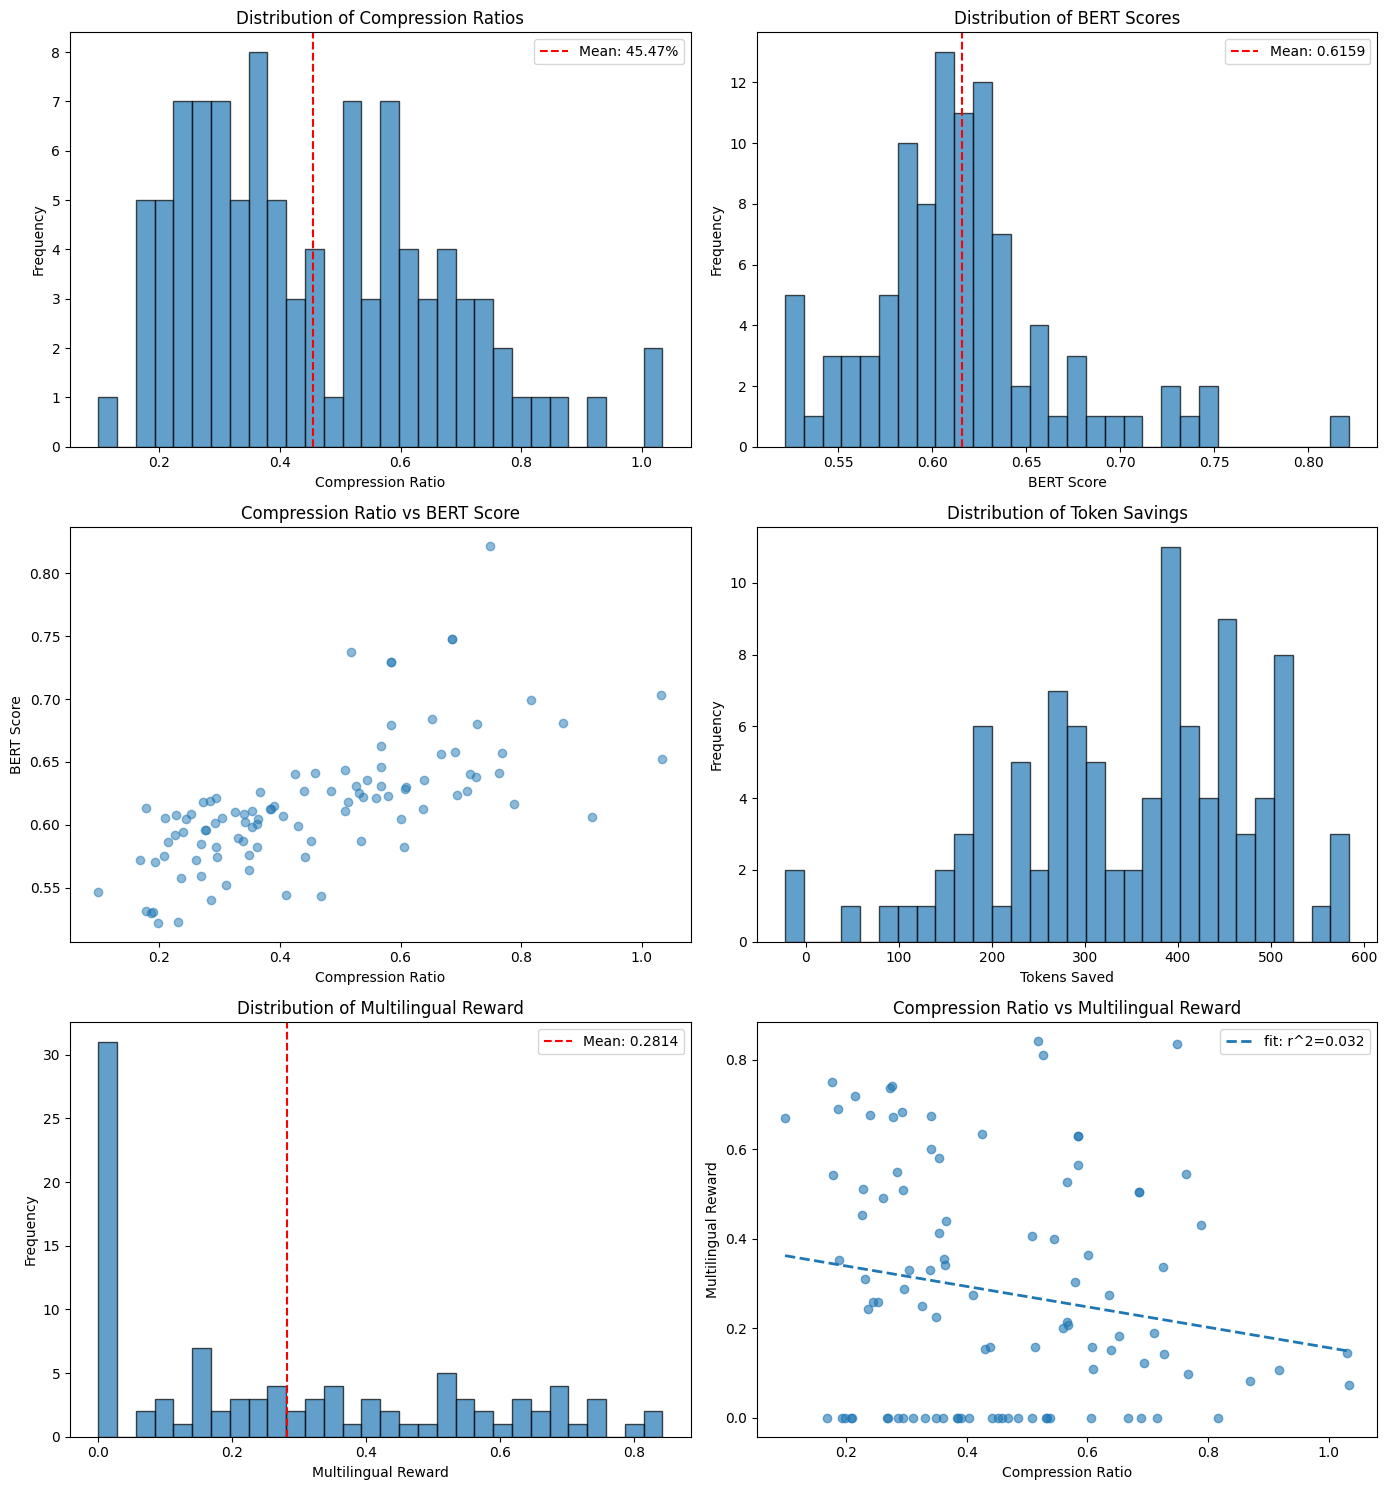

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Row 0 Col 0: Compression ratio distribution
axes[0, 0].hist(eval_results['compression_ratio'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Compression Ratio')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Compression Ratios')
axes[0, 0].axvline(eval_results['compression_ratio'].mean(), color='red', linestyle='--',
                   label=f'Mean: {eval_results["compression_ratio"].mean():.2%}')
axes[0, 0].legend()

# Row 0 Col 1: BERT score distribution (kept)
axes[0, 1].hist(eval_results['bert_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('BERT Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of BERT Scores')
axes[0, 1].axvline(eval_results['bert_score'].mean(), color='red', linestyle='--',
                   label=f'Mean: {eval_results["bert_score"].mean():.4f}')
axes[0, 1].legend()

# Row 1 Col 0: Compression vs BERT scatter (fixed label)
axes[1, 0].scatter(eval_results['compression_ratio'], eval_results['bert_score'], alpha=0.5)
axes[1, 0].set_xlabel('Compression Ratio')
axes[1, 0].set_ylabel('BERT Score')    # fixed label (was BLEU)
axes[1, 0].set_title('Compression Ratio vs BERT Score')

# Row 1 Col 1: Token reduction
axes[1, 1].hist(eval_results['original_tokens'] - eval_results['compressed_tokens'],
                bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Tokens Saved')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Token Savings')

# Row 2 Col 0: Multilingual reward distribution
axes[2, 0].hist(eval_results['multilingual'], bins=30, edgecolor='black', alpha=0.7)
axes[2, 0].set_xlabel('Multilingual Reward')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title('Distribution of Multilingual Reward')
axes[2, 0].axvline(eval_results['multilingual'].mean(), color='red', linestyle='--',
                   label=f'Mean: {eval_results["multilingual"].mean():.4f}')
axes[2, 0].legend()

# Row 2 Col 1: Compression ratio vs Multilingual reward (scatter + linear fit)
x = eval_results['compression_ratio'].to_numpy()
y = eval_results['multilingual'].to_numpy()
axes[2, 1].scatter(x, y, alpha=0.6)
axes[2, 1].set_xlabel('Compression Ratio')
axes[2, 1].set_ylabel('Multilingual Reward')
axes[2, 1].set_title('Compression Ratio vs Multilingual Reward')

if len(x) > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    fit_x = np.linspace(x.min(), x.max(), 100)
    fit_y = slope * fit_x + intercept
    axes[2, 1].plot(fit_x, fit_y, linestyle='--', linewidth=2, label=f'fit: r^2={r_value**2:.3f}')
    axes[2, 1].legend()
    print(f"Linear fit r^2 = {r_value**2:.4f}, p = {p_value:.3g}")
else:
    print("Not enough points to compute regression.")

plt.tight_layout()
plt.show()


In [ ]:
# Save detailed results
eval_results.to_csv('/hpc/home/bfa6/work/github/yapper/results/test/test_results.csv', index=False)
print("Results saved to test_results.csv")

In [27]:
# Find best and worst samples
best_idx = eval_results.sort_values('bert_score', ascending=False).iloc[0]['sample_idx']
worst_idx = eval_results.sort_values('bert_score', ascending=True).iloc[0]['sample_idx']

print("="*80)
print("BEST COMPRESSION (Highest BLEU)")
print("="*80)
print(f"\nOriginal:\n{test_dataset[int(best_idx)]['chunk'][:500]}...")
compressed_best, _, _ = compress_text(test_dataset[int(best_idx)]['chunk'])
print(f"\nCompressed:\n{compressed_best[:500]}...")
print(f"\nBLEU: {eval_results.iloc[int(best_idx)]['bert_score']:.4f}")
print(f"Compression: {eval_results.iloc[int(best_idx)]['compression_ratio']:.2%}")

print("\n" + "="*80)
print("WORST COMPRESSION (Lowest BLEU)")
print("="*80)
print(f"\nOriginal:\n{test_dataset[int(worst_idx)]['chunk'][:500]}...")
compressed_worst, _, _ = compress_text(test_dataset[int(worst_idx)]['chunk'])
print(f"\nCompressed:\n{compressed_worst[:500]}...")
print(f"\nBLEU: {eval_results.iloc[int(worst_idx)]['bert_score']:.4f}")
print(f"Compression: {eval_results.iloc[int(worst_idx)]['compression_ratio']:.2%}")

BEST COMPRESSION (Highest BLEU)

Original:
“I won’t forget,” said Kathleen, confidently, and having given the
street and number, and another good-bye kiss to Kathleen, Nora tore
herself away from the embrace of her twin, and ran swiftly down-stairs.
There was no one in sight, and no one heard the opening and closing of
the front door. At that very moment, Ellen, the cook, was recounting
to a couple of friends--who had dropped in to tea--how she had found
little Miss Kathleen all by herself in the park, “as bold as you
please,” and how sh...
「妳有媽媽嗎？」Kathleen 質問 Mrs. Anderson，後又問 Selma —— 一語雙關，母愛缺席，記憶如煙。<|im_end|>

Compressed:
「妳有媽媽嗎？」Kathleen 質問 Mrs. Anderson，後又問 Selma —— 一語雙關，母愛缺席，記憶如煙。...

BLEU: 0.8217
Compression: 74.89%

WORST COMPRESSION (Lowest BLEU)

Original:
We had finished cataloguing the library and getting it into order,
and very proud I was of my work. The house was in the most
spick-and-span condition, and there was nothing left for us to do.
And now I began the feast of r